<a href="https://colab.research.google.com/github/hyuni7/SeSAC/blob/main/%EB%AA%A8%EB%8D%B8%EC%9D%98%EC%9D%B4%ED%95%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

과적합 Overfitting
과적합은:
훈련 데이터를 너무 잘 외워서 새로운 데이터에서는 성능이 떨어지는 현상

Gini는 데이터가 얼마나 섞여 있는가를 측정합니다.

Entropy 역시 데이터가 얼마나 섞여 있는지, 불확실한지를 나타냅니다.

| Random Forest | XGBoost |
|-----|-----|
| 여러 트리 | 여러 트리 |
| 다수결 | 오류 보완 |
| 비교적 독립적으로 학습 | 순차적으로 학습 |
| 안정적 | 성능이 매우 좋은 경우 많음 |

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [5]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'iris_dataset.csv', 'gdrive', 'sample_data']


In [2]:
rpth = "/content/iris_dataset.csv"

In [6]:
import pandas as pd
df = pd.read_csv(rpth)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [10]:
#x_data = df.drop('species', axis=1)
x_data = df.drop(columns=["species"])
y_data = df['species']

In [11]:
x_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [12]:
y_data

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, stratify=y_data, random_state=261001, test_size=0.3)

In [28]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((105, 4), (45, 4), (105,), (45,))

In [29]:
import numpy as np
np.unique(y_test, return_counts=True)

(array(['setosa', 'versicolor', 'virginica'], dtype=object),
 array([15, 15, 15]))

In [30]:
from sklearn.tree import DecisionTreeClassifier
iris_dt = DecisionTreeClassifier()
iris_dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [32]:
pred = iris_dt.predict(x_test)
print(pred)

['versicolor' 'setosa' 'virginica' 'virginica' 'versicolor' 'setosa'
 'versicolor' 'versicolor' 'virginica' 'setosa' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'versicolor' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'virginica' 'virginica' 'versicolor' 'virginica' 'virginica' 'versicolor'
 'setosa' 'setosa' 'versicolor' 'setosa' 'versicolor' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'versicolor' 'setosa' 'virginica'
 'versicolor' 'virginica']


In [33]:
pred == y_test

,species
50,True
36,True
143,True
115,True
85,True
9,True
68,True
57,True
118,True
33,True


In [34]:
(pred == y_test).mean()

np.float64(0.9777777777777777)

In [38]:
iris_dt.predict(np.array([[2.0, 3.0, 4.0, 5.0],[1.0,1.5,2.0,3.0]]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['virginica', 'virginica'], dtype=object)

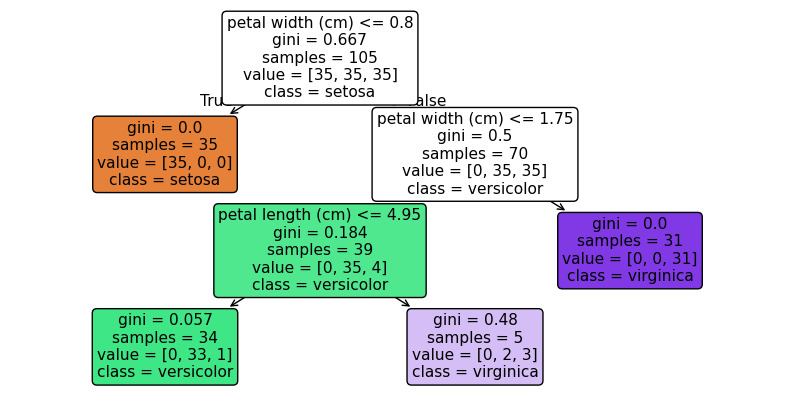

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_tree(iris_dt, feature_names=df.columns, class_names=np.unique(y_train),rounded=True, filled=True)
plt.show()

In [46]:
#Decision Tree가 각 특성을 얼마나 중요하게 사용했는지 보여주는 값
iris_dt.feature_importances_

array([0.        , 0.        , 0.04322817, 0.95677183])

In [53]:
#random_state=777은 실행할 때마다 결과가 달라지지 않도록 난수 기준을 고정하는 값
iris_dt = DecisionTreeClassifier(random_state=777, max_depth=3)
iris_dt.fit(x_train, y_train)
print((pred==y_test).mean())
iris_dt.feature_importances_

0.9777777777777777


array([0.        , 0.        , 0.04322817, 0.95677183])

In [55]:
for dep in range(1,10):
    iris_dt = DecisionTreeClassifier(random_state=777, max_depth=dep)
    iris_dt.fit(x_train, y_train)
    pred = iris_dt.predict(x_test)
    print(dep, (pred==y_test).mean())

1 0.6666666666666666
2 0.9555555555555556
3 0.9777777777777777
4 0.9555555555555556
5 0.9555555555555556
6 0.9555555555555556
7 0.9555555555555556
8 0.9555555555555556
9 0.9555555555555556


In [ ]:
# max_depth 값을 1부터 9까지 바꿔가며 반복
for dep in range(1, 10):

    # 의사결정나무 모델 생성
    # max_depth=dep : 트리의 최대 깊이를 현재 dep 값으로 설정
    iris_dt = DecisionTreeClassifier(
        random_state=777,
        max_depth=dep
    )

    # 학습용 데이터로 모델 학습
    iris_dt.fit(x_train, y_train)

    # 테스트용 데이터의 품종 예측
    pred = iris_dt.predict(x_test)

    # 현재 트리 깊이와 정확도 출력
    # pred == y_test : 예측값과 실제값이 같은지 True/False로 비교
    # .mean() : True를 1, False를 0으로 보고 평균을 내어 정확도 계산
    print(dep, (pred == y_test).mean())

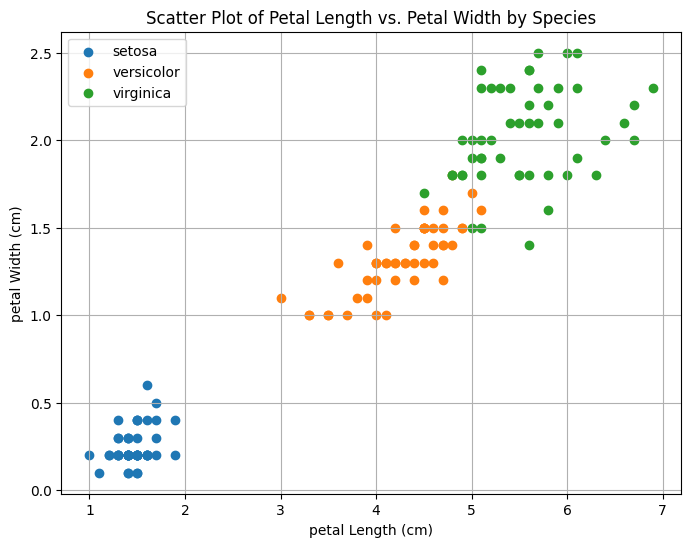

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# species별로 다른 색으로 산점도 그리기
for species_name in y_data.unique():

    subset = df[df['species'] == species_name]

    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species_name
    )

plt.xlabel('petal Length (cm)')
plt.ylabel('petal Width (cm)')
plt.title('Scatter Plot of Petal Length vs. Petal Width by Species')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =====================================================
# 1. 라이브러리 불러오기
# =====================================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt


# =====================================================
# 2. 데이터 불러오기
# =====================================================

df = pd.read_csv('iris_dataset.csv')

print(df.head())


# =====================================================
# 3. 데이터 기본 정보 확인
# =====================================================

print(df.info())

print(df['species'].value_counts())


# =====================================================
# 4. 입력 데이터(X)와 정답 데이터(y) 나누기
# =====================================================

X = df[
    [
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)'
    ]
]

y = df['species']


# =====================================================
# 5. 학습용 데이터와 테스트용 데이터 나누기
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =====================================================
# 6. Decision Tree 모델 만들기
# =====================================================

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)


# =====================================================
# 7. 모델 학습시키기
# =====================================================

model.fit(X_train, y_train)


# =====================================================
# 8. 테스트 데이터로 예측하기
# =====================================================

y_pred = model.predict(X_test)


# =====================================================
# 9. 실제값과 예측값 비교
# =====================================================

result = pd.DataFrame({
    '실제값': y_test,
    '예측값': y_pred
})

print(result)


# =====================================================
# 10. 정확도 확인하기
# =====================================================

accuracy = accuracy_score(y_test, y_pred)

print('정확도:', accuracy)


# =====================================================
# 11. Decision Tree 시각화
# =====================================================

plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.show()


# =====================================================
# 12. 각 특성의 중요도 확인
# =====================================================

importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': model.feature_importances_
})

importance = importance.sort_values(
    by='중요도',
    ascending=False
)

print(importance)


# =====================================================
# 13. 새로운 꽃 데이터 예측하기
# =====================================================

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = model.predict(new_flower)

print('예측된 꽃 종류:', prediction[0])

Decision Tree 전체 실습 코드-wine

1599행, 12개 컬럼이고, 마지막 quality가 와인 품질 점수입니다.

Iris
X = 꽃받침, 꽃잎 길이/너비
y = 꽃 종류

Red Wine
X = 산도, 당도, 알코올, pH 등
y = quality

어떤 와인 성분이 품질 점수 분류에 많이 사용됐는지 확인할 수 있습니다.


x_data = df.drop('quality', axis=1)

y_data = df['quality']

quality를 맞히기 위해 나머지 11개 숫자를 사용하는 것입니다.
| 컬럼명 | 한국어 뜻 | 쉽게 설명 |
|---|---|---|
| `fixed acidity` | 고정 산도 | 쉽게 날아가지 않는 산 성분의 양 |
| `volatile acidity` | 휘발성 산도 | 식초 냄새처럼 휘발되는 산 성분의 양 |
| `citric acid` | 구연산 | 상큼한 맛과 신맛에 영향을 주는 성분 |
| `residual sugar` | 잔당 | 발효 후 남아 있는 당분 |
| `chlorides` | 염화물 | 와인 속 소금 성분 정도 |
| `free sulfur dioxide` | 유리 이산화황 | 미생물 번식과 산화를 막는 이산화황 |
| `total sulfur dioxide` | 총 이산화황 | 와인에 존재하는 전체 이산화황 양 |
| `density` | 밀도 | 와인의 무게감·농도와 관련된 값 |
| `pH` | 산도 지수 | 와인이 얼마나 산성인지 나타내는 값 |
| `sulphates` | 황산염 | 보존성과 항산화에 관련된 성분 |
| `alcohol` | 알코올 도수 | 와인에 포함된 알코올 비율 |
| `quality` | 품질 점수 | 평가자가 매긴 와인의 품질 점수 |

In [ ]:
# =====================================================
# 4. 입력 데이터(X)와 정답 데이터(y) 분리
# =====================================================

# quality를 제외한 나머지 컬럼은 입력값
x_data = df.drop('quality', axis=1)

# quality는 정답값
y_data = df['quality']

print('\n입력 데이터:')
print(x_data.head())

print('\n정답 데이터:')
print(y_data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0           11.6             0.580         0.66            2.20      0.074   
1           10.4             0.610         0.49            2.10      0.200   
2            7.4             1.185         0.00            4.25      0.097   
3           10.4             0.440         0.42            1.50      0.145   
4            8.3             1.020         0.02            3.40      0.084   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  47.0  1.00080  3.25       0.57   
1                  5.0                  16.0  0.99940  3.16       0.63   
2                  5.0                  14.0  0.99660  3.63       0.54   
3                 34.0                  48.0  0.99832  3.38       0.86   
4                  6.0                  11.0  0.99892  3.48       0.49   

   alcohol  quality  
0      9.0        3  
1      8.4        3  
2     10.7        3 

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


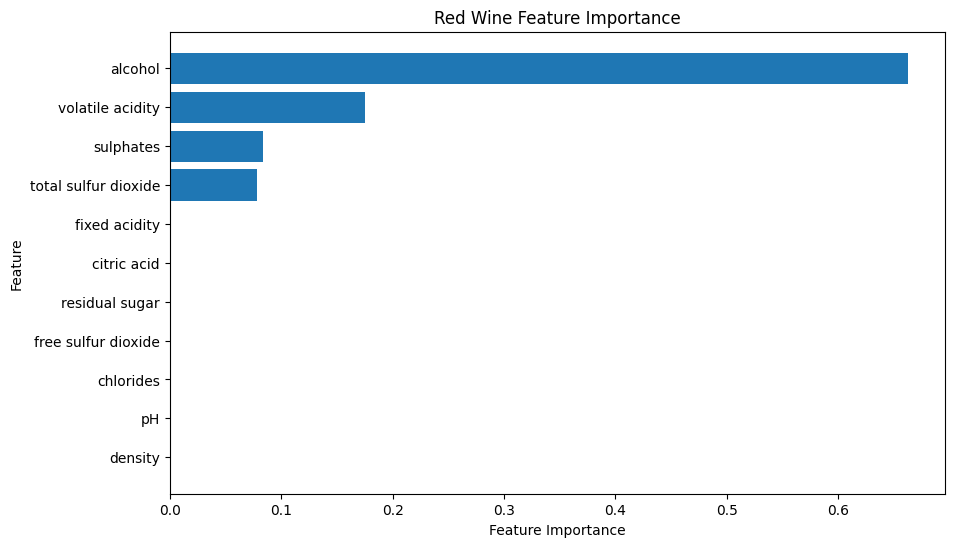

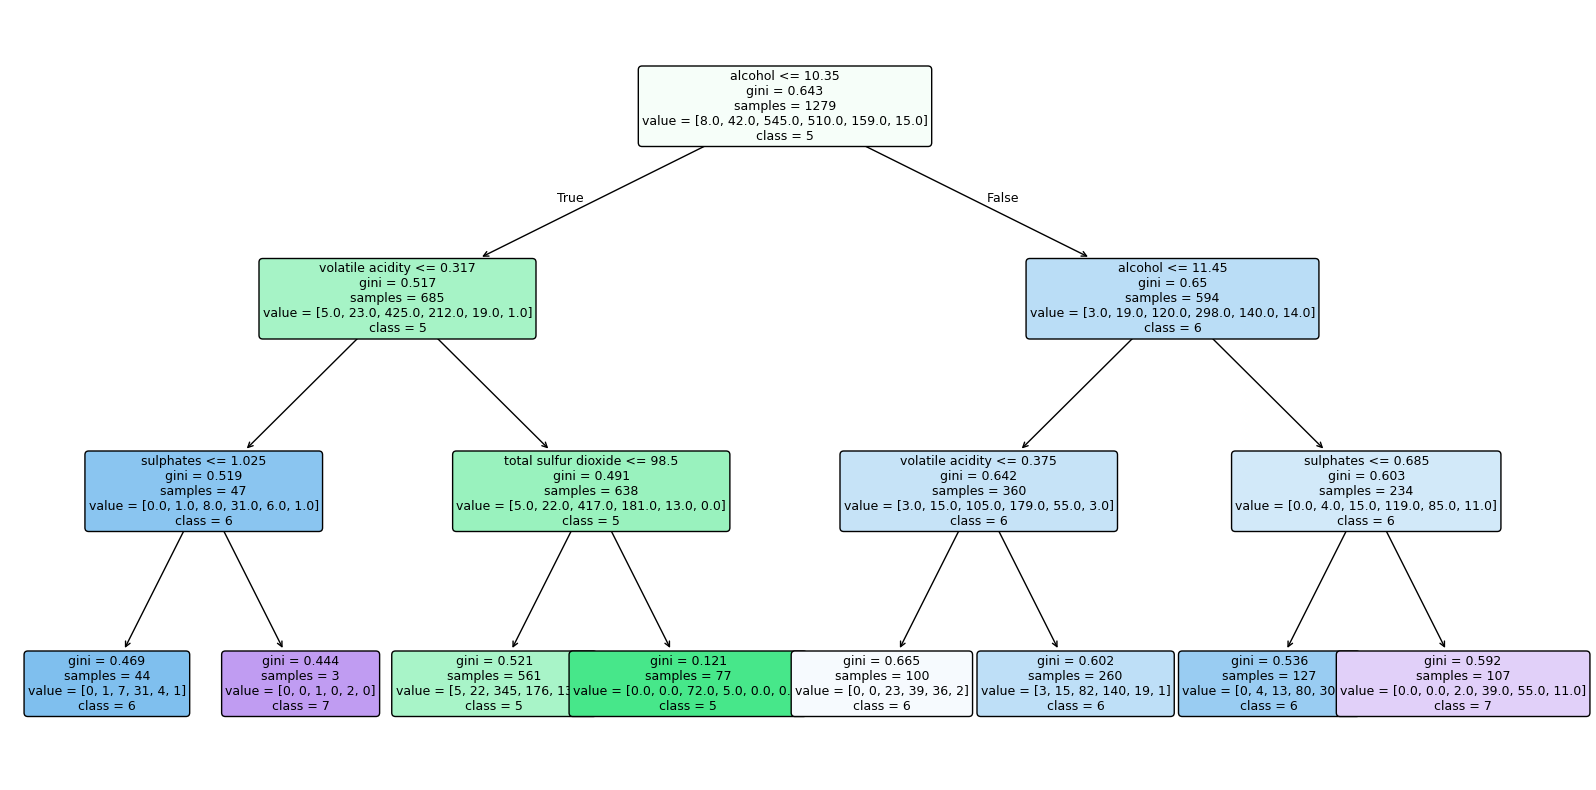

1 0.528125
2 0.540625
3 0.56875
4 0.575
5 0.590625
6 0.6
7 0.6
8 0.596875
9 0.6

새로운 와인의 예측 quality:
5


In [59]:
# =====================================================
# 1. 라이브러리 불러오기
# =====================================================

import pandas as pd # CSV 파일을 읽고 DataFrame 형태로 데이터를 다룰 때
import numpy as np # 숫자 계산과 배열 처리를 위한 라이브러리
import matplotlib.pyplot as plt # 그래프를 그리기 위한 라이브러리

# 데이터를 학습용(train)과 테스트용(test)으로 나누는 함수
from sklearn.model_selection import train_test_split

# Decision Tree 분류 모델과 트리 시각화 함수
# DecisionTreeClassifier : 의사결정나무 모델 생성
# plot_tree              : 학습된 트리를 그림으로 출력
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 모델 성능을 평가하기 위한 함수들
# accuracy_score       : 정확도 계산
# confusion_matrix     : 실제값과 예측값의 분류 결과를 표로 확인
# classification_report: precision, recall, f1-score 등을 한 번에 확인
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# =====================================================
# 2. 데이터 불러오기
# =====================================================

df = pd.read_csv('redwine_quality.csv')

# 데이터 앞부분 확인
print(df.head())


# =====================================================
# 3. 데이터 기본 정보 확인
# =====================================================

print('\n데이터 크기:')
print(df.shape)

print('\n컬럼 이름:')
print(df.columns)

print('\n데이터 정보:')
print(df.info())

print('\n결측치 개수:')
print(df.isnull().sum())

print('\nquality별 데이터 개수:')
print(df['quality'].value_counts().sort_index())


# =====================================================
# 4. 입력 데이터(X)와 정답 데이터(y) 분리
# =====================================================

# quality를 제외한 나머지 컬럼은 입력값
x_data = df.drop('quality', axis=1)

# quality는 정답값
y_data = df['quality']

print('\n입력 데이터:')
print(x_data.head())

print('\n정답 데이터:')
print(y_data.head())


# =====================================================
# 5. 학습용 데이터와 테스트용 데이터 나누기
# =====================================================

x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.2,       # 전체 데이터의 20%를 테스트용으로 사용
    random_state=777,    # 실행할 때마다 같은 결과가 나오도록 고정
    stratify=y_data      # quality 비율을 비슷하게 유지
)

print('\n학습 데이터 크기:')
print(x_train.shape)

print('\n테스트 데이터 크기:')
print(x_test.shape)


# =====================================================
# 6. Decision Tree 모델 만들기
# =====================================================

wine_dt = DecisionTreeClassifier(
    random_state=777,
    max_depth=3
)


# =====================================================
# 7. 모델 학습
# =====================================================

wine_dt.fit(x_train, y_train)


# =====================================================
# 8. 테스트 데이터 예측
# =====================================================

pred = wine_dt.predict(x_test)

print('\n예측 결과 일부:')
print(pred[:20])


# =====================================================
# 9. 정확도 확인
# =====================================================

accuracy = accuracy_score(y_test, pred)

print('\n정확도:')
print(accuracy)


# =====================================================
# 10. 실제값과 예측값 비교
# =====================================================

result = pd.DataFrame({
    '실제 quality': y_test.values,
    '예측 quality': pred
})

print('\n실제값 / 예측값 비교:')
print(result.head(20))


# =====================================================
# 11. 혼동행렬 확인
# =====================================================

print('\n혼동행렬:')
print(confusion_matrix(y_test, pred))


# =====================================================
# 12. 분류 결과 자세히 확인
# =====================================================

print('\n분류 리포트:')
print(classification_report(y_test, pred))


# =====================================================
# 13. 특성 중요도 확인
# =====================================================

importance_df = pd.DataFrame({
    '특성': x_data.columns,
    '중요도': wine_dt.feature_importances_
})

importance_df = importance_df.sort_values(
    by='중요도',
    ascending=False
)

print('\n특성 중요도:')
print(importance_df)


# =====================================================
# 14. 특성 중요도 그래프
# =====================================================

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df['특성'],
    importance_df['중요도']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Red Wine Feature Importance')

plt.gca().invert_yaxis()

plt.show()


# =====================================================
# 15. Decision Tree 시각화
# =====================================================

plt.figure(figsize=(20, 10))

plot_tree(
    wine_dt,
    feature_names=x_data.columns,
    class_names=[str(i) for i in wine_dt.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()


# =====================================================
# 16. max_depth를 1~9까지 바꾸면서 정확도 비교
# =====================================================

for dep in range(1, 10):

    # 트리의 최대 깊이를 dep 값으로 설정
    wine_dt = DecisionTreeClassifier(
        random_state=777,
        max_depth=dep
    )

    # 모델 학습
    wine_dt.fit(x_train, y_train)

    # 테스트 데이터 예측
    pred = wine_dt.predict(x_test)

    # 트리 깊이와 정확도 출력
    print(dep, (pred == y_test).mean())


# =====================================================
# 17. 새로운 와인 데이터 예측 예시
# =====================================================

new_wine = pd.DataFrame(
    [[
        7.4,    # fixed acidity
        0.70,   # volatile acidity
        0.00,   # citric acid
        1.9,    # residual sugar
        0.076,  # chlorides
        11.0,   # free sulfur dioxide
        34.0,   # total sulfur dioxide
        0.9978, # density
        3.51,   # pH
        0.56,   # sulphates
        9.4     # alcohol
    ]],
    columns=x_data.columns
)

prediction = wine_dt.predict(new_wine)

print('\n새로운 와인의 예측 quality:')
print(prediction[0])

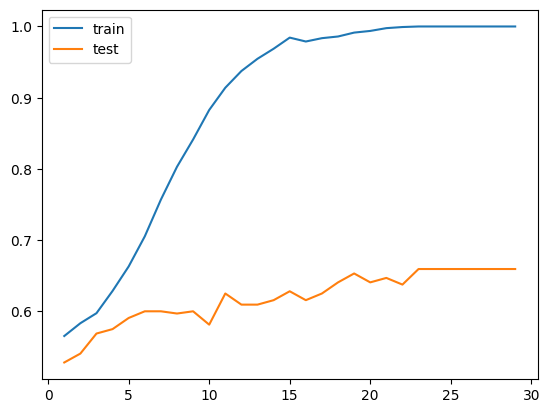

In [64]:
from sklearn.metrics import accuracy_score
test_acc = []
train_acc = []
for dep in range(1,30):
    wine_dt = DecisionTreeClassifier(
        random_state=777, max_depth=dep
    )
    wine_dt.fit(x_train, y_train)
    pred = wine_dt.predict(x_test)
    accuracy = accuracy_score(y_test, pred)
    train_acc.append(wine_dt.score(x_train, y_train))
    test_acc.append(accuracy_score(y_test, pred))
plt.plot(range(1,30), train_acc, label='train')
plt.plot(range(1,30), test_acc, label='test')
plt.legend()
plt.show()

In [66]:
from sklearn.metrics import confusion_matrix
pred = wine_dt.predict(x_test)
confusion_matrix(y_test, pred)

array([[  0,   0,   2,   0,   0,   0],
       [  1,   1,   4,   4,   1,   0],
       [  2,   3, 109,  20,   2,   0],
       [  1,   6,  31,  79,  10,   1],
       [  0,   0,   2,  15,  21,   2],
       [  0,   0,   1,   1,   0,   1]])

이 행이 실제 quality 5라고 가정하면:
- quality 3으로 예측: 2개
- quality 4로 예측: 3개
- quality 5로 정확히 예측: 109개
- quality 6으로 잘못 예측: 20개
- quality 7로 잘못 예측: 2개
즉 대각선 값이 맞춘 개수입니다.

**핵심 정리**

이 화면에서 꼭 기억할 건 3개입니다.

**1. train 정확도만 높다고 좋은 모델이 아니다.**

**2. test 정확도와의 차이가 커지면 과적합을 의심한다.**

**3. confusion matrix의 대각선은 맞춘 개수, 나머지는 틀린 개수다.**